In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

df = pd.DataFrame(data, columns=feature_names)
df['PRICE'] = target

print("Feature names:", feature_names)
print("Data shape:", data.shape)
print("Target shape:", target.shape)
print("\nSample data:")
print(df.head())

Feature names: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Data shape: (506, 13)
Target shape: (506,)

Sample data:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


Number of Missing value:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


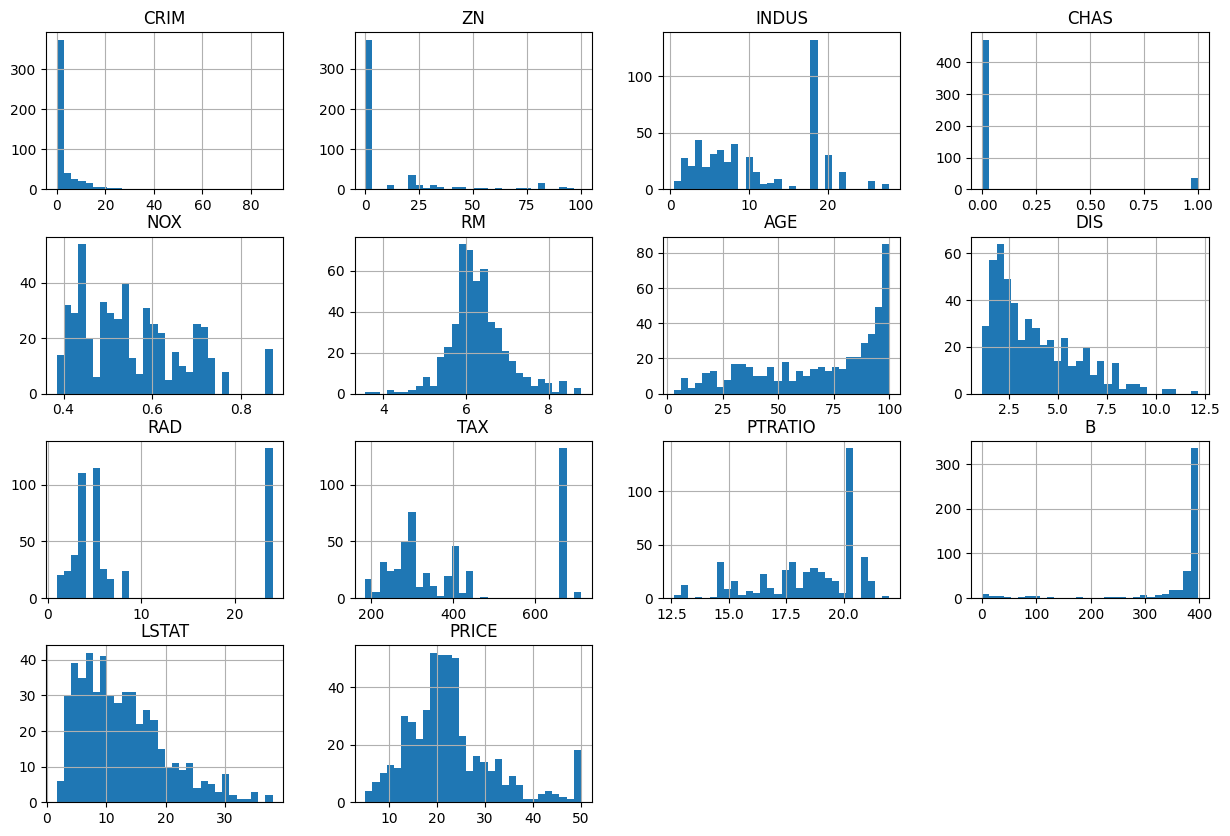

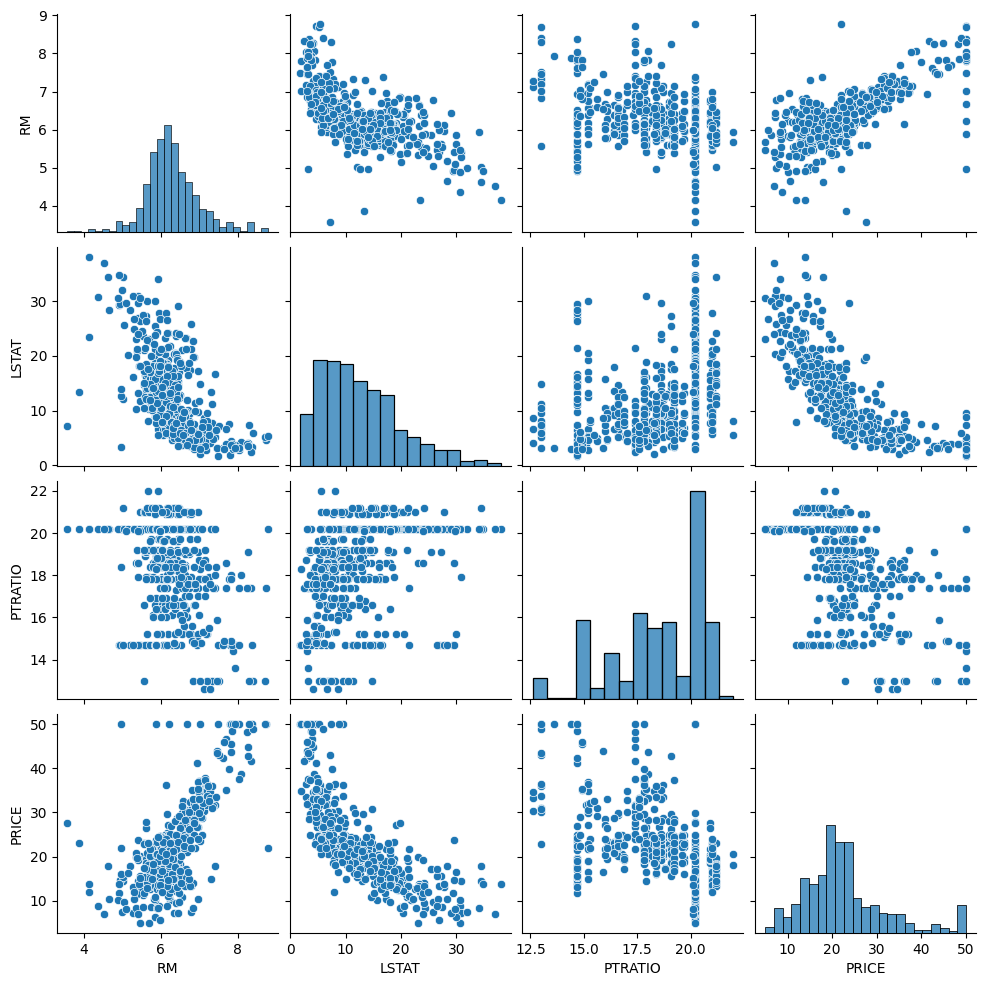

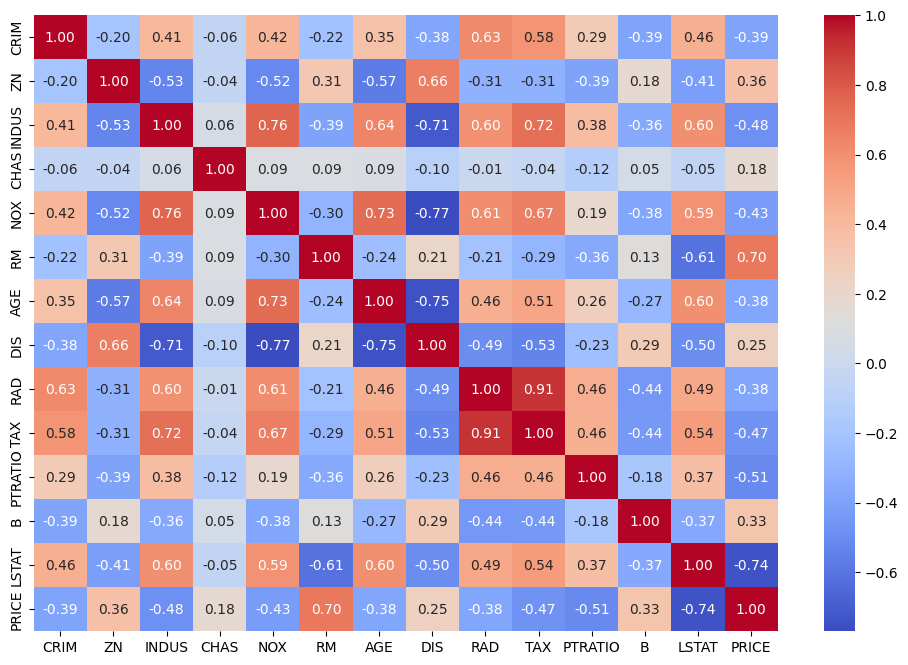

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Number of Missing value:\n", df.isnull().sum())
df.hist(bins=30, figsize=(15, 10))
plt.show()

sns.pairplot(df[['RM', 'LSTAT', 'PTRATIO', 'PRICE']])
plt.show()

corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

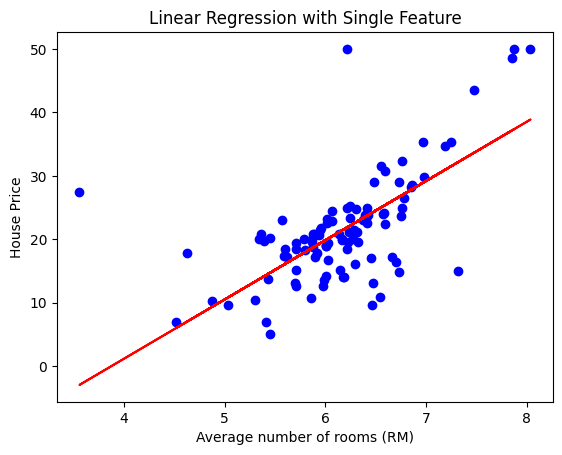

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[['RM']]
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')
plt.xlabel('Average number of rooms (RM)')
plt.ylabel('House Price')
plt.title('Linear Regression with Single Feature')
plt.show()

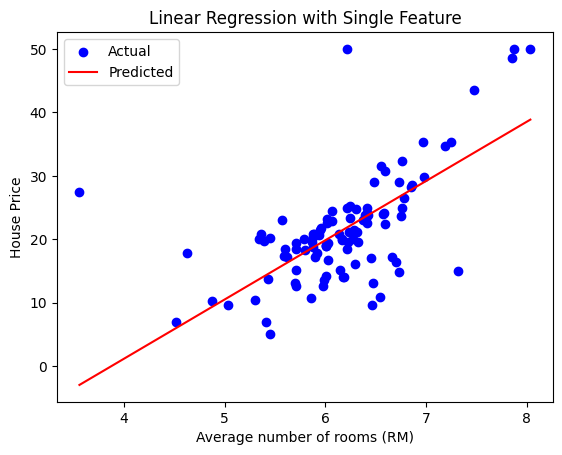

In [ ]:
sorted_idx = X_test.squeeze().argsort()
X_test_sorted = X_test.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test_sorted, y_pred_sorted, color='red', label='Predicted')
plt.xlabel('Average number of rooms (RM)')
plt.ylabel('House Price')
plt.title('Linear Regression with Single Feature')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error(MAE) : {mae:.2f}")
print(f"Mean Squared Error(MSE): {mse:.2f}")
print(f"Root Mean Squared Error(RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error(MAE) : 3.19
Mean Squared Error(MSE): 24.29
Root Mean Squared Error(RMSE): 4.93
R² Score: 0.67


In [ ]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
print(coefficients)

    Feature  Coefficient
0      CRIM    -0.113056
1        ZN     0.030110
2     INDUS     0.040381
3      CHAS     2.784438
4       NOX   -17.202633
5        RM     4.438835
6       AGE    -0.006296
7       DIS    -1.447865
8       RAD     0.262430
9       TAX    -0.010647
10  PTRATIO    -0.915456
11        B     0.012351
12    LSTAT    -0.508571


In [4]:
import pandas as pd

data = {
    'marks': [35, 45, 60, 75, 25, 50, 65, 80, 30, 55],
    'pass': [0, 0, 1, 1, 0, 1, 1, 1, 0, 1]
}

df = pd.DataFrame(data)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df[['marks']]
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

new_marks = [[42]]
prediction = log_model.predict(new_marks)
print("Prediction for marks=42:", "Pass" if prediction[0] == 1 else "Fail")

Accuracy: 0.6666666666666666
Prediction for marks=42: Fail


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
